<h1>Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt

<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [2]:
def sum_prod(X, V):
    '''
    X - матрицы (n, n)
    V - векторы (n, 1)
    Гарантируется, что len(X) == len(V)
    '''
    # Your code goes here
    result = (np.array(X) @ np.array(V)).sum(axis=0)
    return result
def run_tests():
    X1 = [np.eye(2), np.eye(2)]
    V1 = [np.array([[1], [2]]), np.array([[3], [4]])]
    res1 = sum_prod(X1, V1)
    assert np.allclose(res1, [[4], [6]])

    p, n = 5, 3
    X2 = np.random.rand(p, n, n)
    V2 = np.random.rand(p, n, 1)
    res2 = sum_prod(X2, V2)
    assert res2.shape == (n, 1)

    print("Тесты пройдены")

run_tests()

Тесты пройдены


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [3]:
def binarize(M, threshold=0.5):
    # Your code goes here
    m_np=np.array(M)
    return np.where(m_np > threshold, 1, 0)
def test_binarize():
    M1 = [[0.1, 0.8], [0.5, 0.6]]
    res1 = binarize(M1, threshold=0.5)
    expected1 = [[0, 1], [0, 1]]
    assert np.array_equal(res1, expected1)

    M2 = [1, 2, 3, 4, 5]
    res2 = binarize(M2, threshold=3)
    expected2 = [0, 0, 0, 1, 1]
    assert np.array_equal(res2, expected2)

    M3 = [[0, 0], [0, 0]]
    res3 = binarize(M3, threshold=1)
    assert np.all(res3 == 0)

    print("Все тесты бинаризации пройдены!")

test_binarize()

Все тесты бинаризации пройдены!


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [7]:
def unique_rows(mat):
    arr = np.array(mat)
    return [sorted(list(set(row))) for row in arr]

def unique_columns(mat):
    arr = np.array(mat).T
    return [sorted(list(set(col))) for col in arr]
def test_uniques():
    test_mat = [
        [1, 2, 2, 3],
        [4, 4, 4, 4],
        [5, 6, 7, 8]
    ]
    
    u_rows = unique_rows(test_mat)
    assert u_rows[0] == [1, 2, 3] 
    assert u_rows[1] == [4]       
    assert u_rows[2] == [5, 6, 7, 8]
    
    u_cols = unique_columns(test_mat)
    assert u_cols[0] == [1, 4, 5]
    assert len(u_cols) == 4 
    
    print("Тесты пройдены")

test_uniques()

Тесты пройдены


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

Мат. ожидание строк: [-0.01153211  0.14466767 -0.04642685 -0.23212544 -0.05393358 -0.19876752
  0.14953995 -0.00373557 -0.46403643 -0.03202993 -0.12455065 -0.19604543
 -0.03730358 -0.02007677 -0.33275373 -0.35327504 -0.0981281  -0.06417766
  0.19546298 -0.43483937]
Дисперсия строк: [0.8272794  1.55842272 0.55228121 0.64090803 0.96897332 0.89988875
 1.57604023 1.05576002 0.5385432  1.02225552 1.15183304 0.82628496
 0.52855051 1.08037946 1.1134754  1.3678325  0.91765412 0.38115495
 0.89768018 0.66643521]
Мат. ожидание столбцов: [-0.21833285  0.16393031 -0.26588506  0.03337093  0.02542224 -0.20858441
 -0.14627963 -0.17056552 -0.2424347  -0.23890302 -0.37010739  0.07391417
 -0.33347853 -0.09722571  0.07010816 -0.08770413  0.00327135  0.03390753
 -0.05292961 -0.1855613 ]
Дисперсия столбцов: [0.8272794  1.55842272 0.55228121 0.64090803 0.96897332 0.89988875
 1.57604023 1.05576002 0.5385432  1.02225552 1.15183304 0.82628496
 0.52855051 1.08037946 1.1134754  1.3678325  0.91765412 0.38115495
 0

IndexError: index 10 is out of bounds for axis 0 with size 10

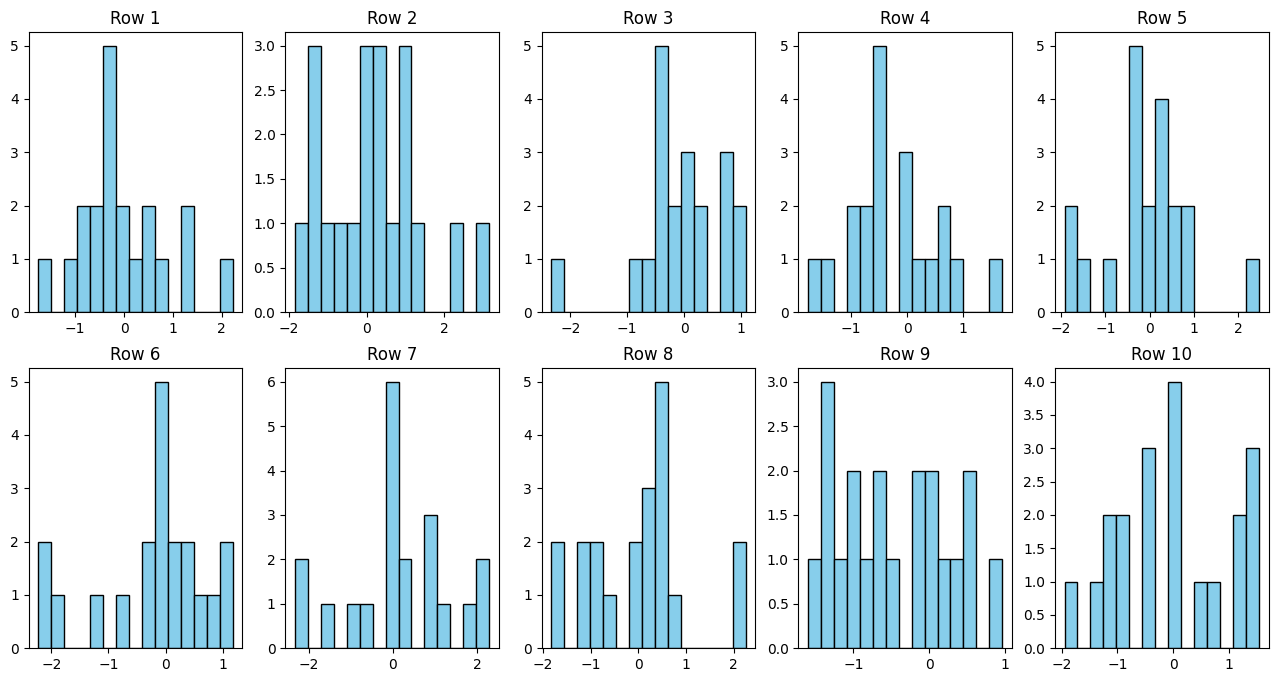

In [18]:
def analyze_matrix(m,n):
    matrix=np.random.normal(loc=0,scale=1,size=(m,n))
    rowmean=np.mean(matrix,axis=1)
    rowvar=np.var(matrix,axis=1)
    colmean=np.mean(matrix,axis=0)
    colvar=np.var(matrix,axis=1)
    print(f"Мат. ожидание строк: {rowmean}")
    print(f"Дисперсия строк: {rowvar}")
    print(f"Мат. ожидание столбцов: {colmean}")
    print(f"Дисперсия столбцов: {colvar}")
    fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(16, 8))
    axes = axes.flatten()
    for i in range (m):
        axes[i].hist(matrix[i, :], bins=15, color='skyblue', edgecolor='black')
        axes[i].set_title(f"Row {i+1}")
    plt.tight_layout()
    plt.show()
    for j in range(n):
        plt.subplot(1, n, j + 1)
        axes[i].hist(matrix[:,j], bins=15, color='skyblue', edgecolor='black')
        axes[i].set_title(f"Col {j+1}")  
    plt.tight_layout() 
    plt.show() 
    return matrix
mat = analyze_matrix(20, 20)

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [ ]:
def chess(m, n, a, b):
    # Your code goes here
    pass

<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

In [1]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    # Your code goes here
    pass

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    # Your code goes here
    pass

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [ ]:
# Your code goes here

<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [ ]:
# Your code goes here